In [1]:
import pandas as pd
import numpy as np
import utils
import matplotlib.pyplot as plt
import csv

In [2]:
data_array = utils.load_jsonl("../../data/v3/docs_dataset_chunked.jsonl")
data_df = pd.DataFrame(data_array)

In [3]:
# how many chunks per doc
doc_appreance_obj = {}
default_topics_dict = {"voie": 0, "caténaire": 0, "matériel roulant": 0, "signalisation":0, "incident":0, "rail":0, "non-affilier":0}
for i in range(data_df.shape[0]):
  chunk = data_df.iloc[i]
  if chunk["doc_id"] not in doc_appreance_obj:
    doc_appreance_obj[chunk["doc_id"]] = {}
    doc_appreance_obj[chunk["doc_id"]]["title"] = chunk["doc_title"]
    doc_appreance_obj[chunk["doc_id"]]["source"] = chunk["source"]
    doc_appreance_obj[chunk["doc_id"]]["count"] = 1
    doc_appreance_obj[chunk["doc_id"]]["chunks_lengths"] = [len(chunk.text.split())]
    doc_appreance_obj[chunk["doc_id"]]["topics"] = default_topics_dict.copy()
    doc_appreance_obj[chunk["doc_id"]]["topics"][chunk["topic"]] = 1
  else:
    doc_appreance_obj[chunk["doc_id"]]["count"] += 1
    doc_appreance_obj[chunk["doc_id"]]["topics"][chunk["topic"]] += 1
    doc_appreance_obj[chunk["doc_id"]]["chunks_lengths"].append(len(chunk.text.split()))


In [4]:
doc_appreance = []
for key, val in doc_appreance_obj.items():
  doc_appreance.append({
    "doc_id":key,
    "title": val["title"],
    "count": val["count"],
    "mean_chunks_length": np.mean(val["chunks_lengths"]),
    "chunks_lengths": val["chunks_lengths"],
    "topics": val["topics"],
    "source": val["source"]
  })
  
doc_appreance_df = pd.DataFrame(doc_appreance)
display(doc_appreance_df)

nb_docs = doc_appreance_df.index[-1] + 1
nb_chunks = data_df.index[-1] + 1

,doc_id,title,count,mean_chunks_length,chunks_lengths,topics,source
0,0,Société nationale des chemins de fer français,74,128.878378,"[134, 134, 132, 139, 138, 125, 130, 125, 136, ...","{'voie': 6, 'caténaire': 30, 'matériel roulant...",wikipedia
1,1,Réaumur - Sébastopol (métro de Paris),6,128.666667,"[123, 121, 130, 135, 150, 113]","{'voie': 1, 'caténaire': 2, 'matériel roulant'...",wikipedia
2,2,Grands Boulevards (métro de Paris),7,117.714286,"[117, 116, 133, 130, 117, 126, 85]","{'voie': 2, 'caténaire': 0, 'matériel roulant'...",wikipedia
3,3,Thalys,17,120.411765,"[131, 141, 124, 129, 122, 130, 135, 139, 125, ...","{'voie': 0, 'caténaire': 6, 'matériel roulant'...",wikipedia
4,4,Eurostar,28,133.464286,"[141, 130, 130, 133, 128, 146, 130, 116, 146, ...","{'voie': 1, 'caténaire': 11, 'matériel roulant...",wikipedia
...,...,...,...,...,...,...,...
16369,16384,"ITE Km 53,3 de la section de ligne de Portet S...",37,138.837838,"[128, 132, 216, 145, 122, 130, 125, 135, 132, ...","{'voie': 29, 'caténaire': 0, 'matériel roulant...",Réseau SNCF
16370,16385,Etablissement PL de Carbonne Points 482 et 484,51,135.803922,"[126, 133, 127, 127, 150, 289, 126, 135, 124, ...","{'voie': 36, 'caténaire': 2, 'matériel roulant...",Réseau SNCF
16371,16386,Dessertes Gare de Vaires Poste 5VP,105,133.038095,"[130, 131, 127, 119, 161, 139, 134, 122, 131, ...","{'voie': 66, 'caténaire': 22, 'matériel roulan...",Réseau SNCF
16372,16387,Gare de Corbehem - Manoeuvres,120,140.158333,"[131, 132, 133, 130, 136, 96, 146, 144, 211, 1...","{'voie': 96, 'caténaire': 5, 'matériel roulant...",Réseau SNCF


In [5]:
print("Nb docs", nb_docs)
print("Nb chunks", nb_chunks)
print("Chunks per doc Mean :", doc_appreance_df["count"].mean())
print("Chunks per doc Mean :", np.array(doc_appreance_df["chunks_lengths"].sum()).mean())
print("Chunks Length Min :", doc_appreance_df["mean_chunks_length"].min())
print("Chunks Length Max :", doc_appreance_df["mean_chunks_length"].max())

Nb docs 16374
Nb chunks 207649
Chunks per doc Mean : 12.681629412483206
Chunks per doc Mean : 129.7677667602541
Chunks Length Min : 1.0
Chunks Length Max : 403.75


Text(0.5, 0, 'Taille Moyenne des chunks (mots) par document')

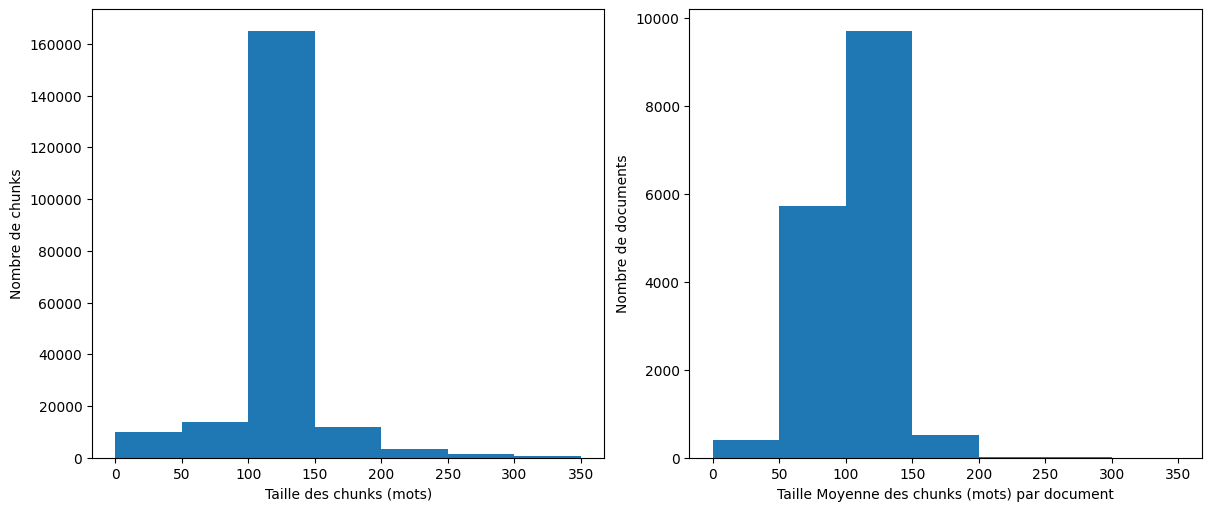

In [6]:
chunks_lengths = []
for array in doc_appreance_df["chunks_lengths"].values:
  chunks_lengths.extend(array)


fig, axs = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

axs[0].hist(chunks_lengths, [i*50 for i in range(8)])
axs[0].set_ylabel("Nombre de chunks")
axs[0].set_xlabel("Taille des chunks (mots)")

axs[1].hist(doc_appreance_df["mean_chunks_length"].tolist(), [i*50 for i in range(8)])
axs[1].set_ylabel("Nombre de documents")
axs[1].set_xlabel("Taille Moyenne des chunks (mots) par document")
# fig.savefig("../../data/v2/statistics/Chunks sizes histogramme.png")

In [7]:
data_df["chunk_len"] = data_df["text"].str.split().str.len()

avg_len_by_source = (
    data_df.groupby("source", dropna=False)
    .agg(
        mean_chunk_length=("chunk_len", "mean"),
        median_chunk_length=("chunk_len", "median"),
        nb_chunks=("chunk_len", "size"),
        nb_docs=("doc_id", "nunique"),
    )
    .sort_values("mean_chunk_length", ascending=False)
)

display(avg_len_by_source)

,mean_chunk_length,median_chunk_length,nb_chunks,nb_docs
source,,,,
Réseau SNCF,135.494793,130.0,149410,7014
wikipedia,115.075293,129.0,58239,9360


In [33]:
source_groups = [group for group in doc_appreance_df.groupby("source", dropna=False)]
sncf_group = source_groups[0][1]
wiki_group = source_groups[1][1]
mean_sncf_doc_length = sum(sncf_group["chunks_lengths"].sum()) / sncf_group.shape[0]
mean_wiki_doc_length = sum(wiki_group["chunks_lengths"].sum()) / wiki_group.shape[0]
print("Mean length of a sncf doc : ", mean_sncf_doc_length)
print("Mean length of a wiki doc : ", mean_wiki_doc_length)

Mean length of a sncf doc :  2886.2670373538635
Mean length of a wiki doc :  716.0117521367522


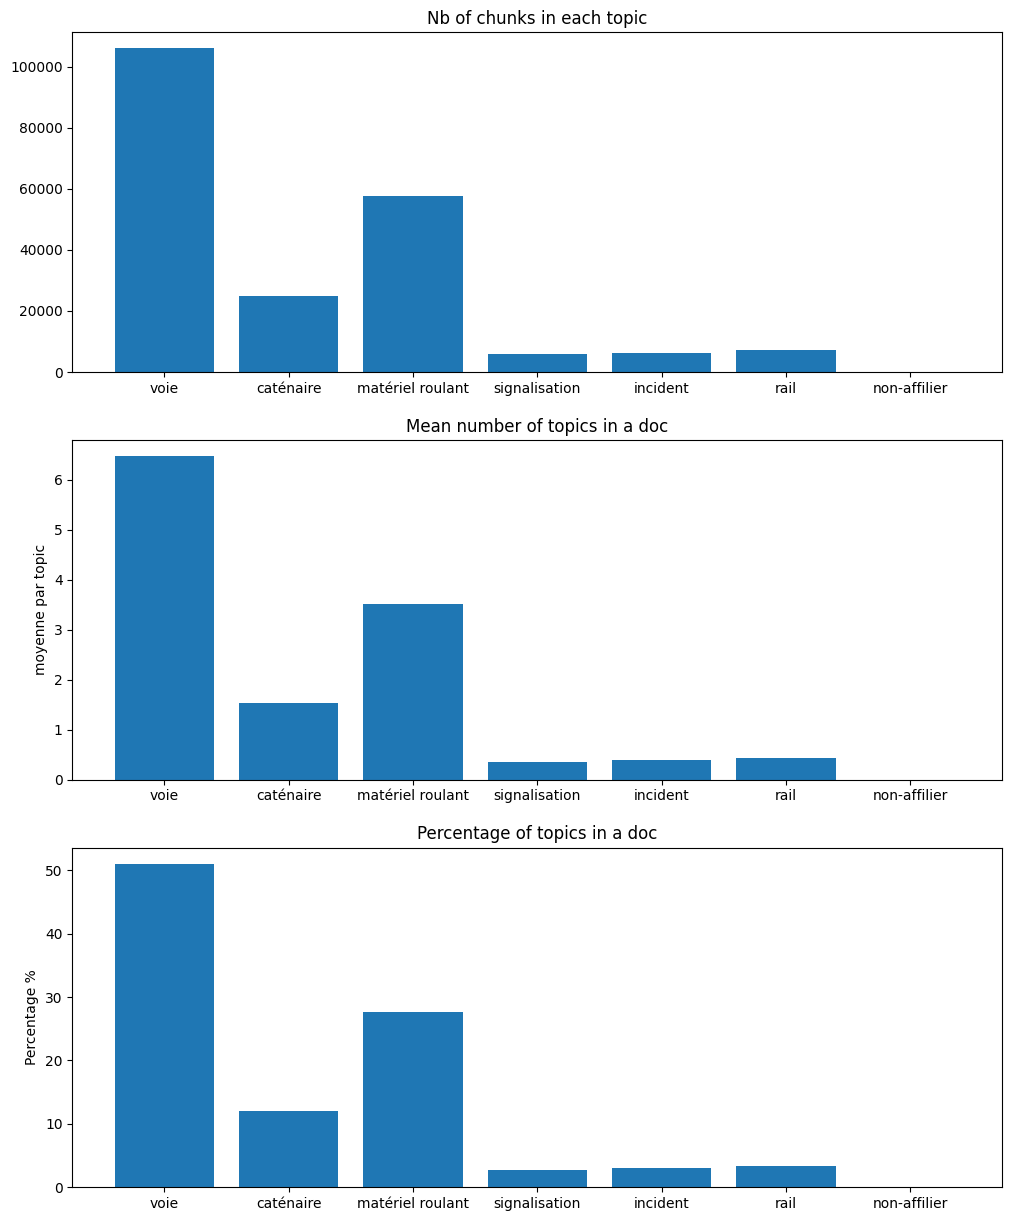

topics_sums {'voie': 105959, 'caténaire': 24948, 'matériel roulant': 57541, 'signalisation': 5787, 'incident': 6308, 'rail': 7103, 'non-affilier': 3}
mean_topic_per_doc :  [6.471173812141199, 1.5236350311469402, 3.514168804201783, 0.3534261634298278, 0.385244900451936, 0.4337974838158055, 0.00018321729571271528]
Pourcentage :  [51.027936566032096, 12.014505246834803, 27.71070412089632, 2.786914456607063, 3.0378186266247376, 3.4206762373042974, 0.001444745700677586]


In [9]:
topics_sum = {}
for doc_topics in doc_appreance_df["topics"].values:
  for key, item in doc_topics.items():
    if key in topics_sum:
      topics_sum[key] += item
    else:
      topics_sum[key] = item

fig, axs = plt.subplots(3, 1, figsize=(12,15))
axs[0].bar([key for key in topics_sum.keys()], [val for val in topics_sum.values()])
axs[0].set_title("Nb of chunks in each topic")

mean_topic_per_doc = [val / nb_docs for val in topics_sum.values()]

axs[1].bar([key for key in topics_sum.keys()], mean_topic_per_doc)
axs[1].set_ylabel("moyenne par topic")
axs[1].set_title("Mean number of topics in a doc")

mean_sum = sum(mean_topic_per_doc)

axs[2].bar([key for key in topics_sum.keys()], [val * 100 / mean_sum for val in mean_topic_per_doc])
axs[2].set_ylabel("Percentage %")
axs[2].set_title("Percentage of topics in a doc")
plt.show()

print("topics_sums", topics_sum)
print("mean_topic_per_doc : ", mean_topic_per_doc)
print("Pourcentage : ", [val * 100 / mean_sum for val in mean_topic_per_doc])

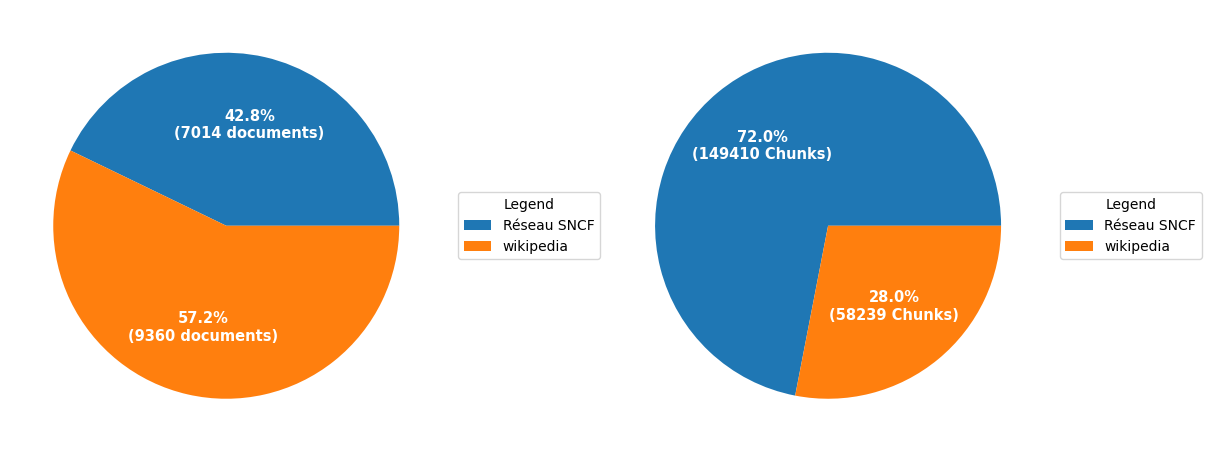

In [34]:
def plot_circle_slice(axe, counts, keys, metric="chunks"):
  wedges, texts, autotexts = axe.pie(
    counts,
    textprops=dict(color="w"),
    autopct=lambda pct: f"{pct:.1f}%\n({int(np.round(pct/100.*np.sum(counts)))} {metric})"
  )
  axe.legend(
    wedges,
    keys,
    title="Legend",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
  )
  plt.setp(autotexts, size=10.5, weight="bold")
  return axe

docs_source_counts = doc_appreance_df["source"].value_counts()
chunks_source_counts = data_df["source"].value_counts()

fig, axes = plt.subplots(ncols=2, figsize=(12,6), constrained_layout=True)

plot_circle_slice(axes[0], docs_source_counts.values[::-1], docs_source_counts.keys()[::-1], "documents")
plot_circle_slice(axes[1], chunks_source_counts.values, chunks_source_counts.keys(), "Chunks")

fig.savefig("../../data/v3/statistics/Docs and Chunks Sources Distribution.pdf")

# fig, ax = plot_circle_slice([14145, 9361], ["Not Found", "Found"], "documents")
# fig2, ax2 = plot_circle_slice(chunks_source_counts.values, chunks_source_counts.keys())
# fig3, ax3 = plot_circle_slice(docs_source_counts.values, docs_source_counts.keys(), "documents")

# fig3.savefig("../../data/v3/statistics/Docs Sources Distribution.png")
# fig2.savefig("../../data/v3/statistics/Chunks Sources Distribution.png")
# fig.savefig("../../data/v3/statistics/Docs Found Distribution.png")

### Explorer la dataset et supprimé les pages wiki inutil (communes, culture populaire, etc.)

In [ ]:
import pandas as pd
import numpy as np
import utils
import csv
pages_df = pd.read_csv("../../data/related_pages_stream.csv")

In [ ]:
element = pages_df.loc[pages_df["title"] == "Hector Guimard"]
print(element["route"].values)
print(element["url"].values)

<ArrowStringArray>
['Catégorie:Transport ferroviaire en France/Catégorie:Transport ferroviaire en France par région/Catégorie:Transport ferroviaire en Île-de-France/Catégorie:Métro de Paris/Catégorie:Histoire du métro de Paris']
Length: 1, dtype: str
<ArrowStringArray>
['https://fr.wikipedia.org/wiki/Hector_Guimard']
Length: 1, dtype: str


In [ ]:
prohibited_titles = ["commune desservie", "culture populaire"]

def not_in_prohibited(title):
  for prohibited_title in prohibited_titles:
    if prohibited_title in title.lower():
      return False

  return True

In [ ]:
print(f"I have {pages_df.shape[0]} Total elements")
mask = pd.Series([not_in_prohibited(route) for route in pages_df["route"].values])
display(mask)
res = pages_df.loc[mask]
print(f"Without the : cummunes, culture générale we have {res.shape[0]}")
display(res)

res.to_csv("../../data/related_pages.csv", index=False, mode="w")

I have 23573 Total elements


0        True
1        True
2        True
3        True
4        True
         ... 
23568    True
23569    True
23570    True
23571    True
23572    True
Length: 23573, dtype: bool

Without the : cummunes, culture générale we have 23505


,title,url,route
0,Transport ferroviaire en France,https://fr.wikipedia.org/wiki/Transport_ferrov...,Catégorie:Transport ferroviaire en France
1,Association française du rail,https://fr.wikipedia.org/wiki/Association_fran...,Catégorie:Transport ferroviaire en France
2,Billet populaire de congés annuel,https://fr.wikipedia.org/wiki/Billet_populaire...,Catégorie:Transport ferroviaire en France
3,Block automatique à permissivité restreinte,https://fr.wikipedia.org/wiki/Block_automatiqu...,Catégorie:Transport ferroviaire en France
4,Block automatique lumineux,https://fr.wikipedia.org/wiki/Block_automatiqu...,Catégorie:Transport ferroviaire en France
...,...,...,...
23568,Tunnel des Gouttes,https://fr.wikipedia.org/wiki/Tunnel_des_Gouttes,Catégorie:Transport ferroviaire en France/Caté...
23569,Tunnel du Hom,https://fr.wikipedia.org/wiki/Tunnel_du_Hom,Catégorie:Transport ferroviaire en France/Caté...
23570,Projet de pont ou de tunnel Jersey-France,https://fr.wikipedia.org/wiki/Projet_de_pont_o...,Catégorie:Transport ferroviaire en France/Caté...
23571,Tunnel ferroviaire de Saint-Rimay,https://fr.wikipedia.org/wiki/Tunnel_ferroviai...,Catégorie:Transport ferroviaire en France/Caté...


In [ ]:
print(f"I have {pages_df.shape[0]} Total elements")
mask = pd.Series(["Commune desservie" not in route for route in pages_df["route"].values])
display(mask)
res = pages_df.loc[mask]
print(f"Without the cummunes we have {res.shape[0]}")
display(res)

communes = pages_df.loc[mask.map(lambda val: not val)]
print(f"With the cummunes we have {communes.shape[0]}")
display(communes)

I have 29566 Total elements


0        True
1        True
2        True
3        True
4        True
         ... 
29561    True
29562    True
29563    True
29564    True
29565    True
Length: 29566, dtype: bool

Without the cummunes we have 23573


,title,url,route
0,Transport ferroviaire en France,https://fr.wikipedia.org/wiki/Transport_ferrov...,Catégorie:Transport ferroviaire en France
1,Association française du rail,https://fr.wikipedia.org/wiki/Association_fran...,Catégorie:Transport ferroviaire en France
2,Billet populaire de congés annuel,https://fr.wikipedia.org/wiki/Billet_populaire...,Catégorie:Transport ferroviaire en France
3,Block automatique à permissivité restreinte,https://fr.wikipedia.org/wiki/Block_automatiqu...,Catégorie:Transport ferroviaire en France
4,Block automatique lumineux,https://fr.wikipedia.org/wiki/Block_automatiqu...,Catégorie:Transport ferroviaire en France
...,...,...,...
29561,Tunnel des Gouttes,https://fr.wikipedia.org/wiki/Tunnel_des_Gouttes,Catégorie:Transport ferroviaire en France/Caté...
29562,Tunnel du Hom,https://fr.wikipedia.org/wiki/Tunnel_du_Hom,Catégorie:Transport ferroviaire en France/Caté...
29563,Projet de pont ou de tunnel Jersey-France,https://fr.wikipedia.org/wiki/Projet_de_pont_o...,Catégorie:Transport ferroviaire en France/Caté...
29564,Tunnel ferroviaire de Saint-Rimay,https://fr.wikipedia.org/wiki/Tunnel_ferroviai...,Catégorie:Transport ferroviaire en France/Caté...


With the cummunes we have 5993


,title,url,route
213,Croix (Nord),https://fr.wikipedia.org/wiki/Croix_(Nord),Catégorie:Transport ferroviaire en France/Caté...
214,Lille,https://fr.wikipedia.org/wiki/Lille,Catégorie:Transport ferroviaire en France/Caté...
215,La Madeleine (Nord),https://fr.wikipedia.org/wiki/La_Madeleine_(Nord),Catégorie:Transport ferroviaire en France/Caté...
216,Marcq-en-Barœul,https://fr.wikipedia.org/wiki/Marcq-en-Barœul,Catégorie:Transport ferroviaire en France/Caté...
217,Mouvaux,https://fr.wikipedia.org/wiki/Mouvaux,Catégorie:Transport ferroviaire en France/Caté...
...,...,...,...
29414,Hérin,https://fr.wikipedia.org/wiki/Hérin,Catégorie:Transport ferroviaire en France/Caté...
29415,Marly (Nord),https://fr.wikipedia.org/wiki/Marly_(Nord),Catégorie:Transport ferroviaire en France/Caté...
29416,La Sentinelle (Nord),https://fr.wikipedia.org/wiki/La_Sentinelle_(N...,Catégorie:Transport ferroviaire en France/Caté...
29417,Valenciennes,https://fr.wikipedia.org/wiki/Valenciennes,Catégorie:Transport ferroviaire en France/Caté...


In [ ]:
import requests
r = requests.get("https://geo.api.gouv.fr/communes?fields=nom&format=json")
r.raise_for_status()
communes_names = sorted({c["nom"] for c in r.json()})

In [ ]:
is_commune_mask = pd.Series([title not in communes_names for title in communes["title"].values])
display(is_commune_mask)

val = is_commune_mask.value_counts()
print("'True' is non standard commune with commune route and 'False' is a commune with a commune route")
display(val)

communes = communes.reset_index()
remaining_stuff = communes.loc[is_commune_mask]
print("non communes that have a commune route are : ", remaining_stuff.shape[0])
display(remaining_stuff)

remaining_stuff_2  = communes.loc[is_commune_mask.map(lambda val: not val)].sort_values("title")
print("Communes that have a commune route are : ", remaining_stuff_2.shape[0])
display(remaining_stuff_2)

0        True
1       False
2        True
3       False
4       False
        ...  
5988    False
5989     True
5990     True
5991    False
5992    False
Length: 5993, dtype: bool

'True' is non standard commune with commune route and 'False' is a commune with a commune route


True     5741
False     252
Name: count, dtype: int64

non communes that have a commune route are :  5741


,index,title,url,route
0,213,Croix (Nord),https://fr.wikipedia.org/wiki/Croix_(Nord),Catégorie:Transport ferroviaire en France/Caté...
2,215,La Madeleine (Nord),https://fr.wikipedia.org/wiki/La_Madeleine_(Nord),Catégorie:Transport ferroviaire en France/Caté...
10,8004,Fontaine (Isère),https://fr.wikipedia.org/wiki/Fontaine_(Isère),Catégorie:Transport ferroviaire en France/Caté...
42,9999,Olivet (Loiret),https://fr.wikipedia.org/wiki/Olivet_(Loiret),Catégorie:Transport ferroviaire en France/Caté...
46,14112,Liste des communes desservies par le métro de ...,https://fr.wikipedia.org/wiki/Liste_des_commun...,Catégorie:Transport ferroviaire en France/Caté...
...,...,...,...,...
5965,29391,Max Milner,https://fr.wikipedia.org/wiki/Max_Milner,Catégorie:Transport ferroviaire en France/Caté...
5966,29392,Jacques Vernier (pilote),https://fr.wikipedia.org/wiki/Jacques_Vernier_...,Catégorie:Transport ferroviaire en France/Caté...
5967,29393,Marcel Vigreux,https://fr.wikipedia.org/wiki/Marcel_Vigreux,Catégorie:Transport ferroviaire en France/Caté...
5989,29415,Marly (Nord),https://fr.wikipedia.org/wiki/Marly_(Nord),Catégorie:Transport ferroviaire en France/Caté...


Communes that have a commune route are :  252


,index,title,url,route
250,23676,Ambilly,https://fr.wikipedia.org/wiki/Ambilly,Catégorie:Transport ferroviaire en France/Caté...
251,23677,Angers,https://fr.wikipedia.org/wiki/Angers,Catégorie:Transport ferroviaire en France/Caté...
252,23678,Annemasse,https://fr.wikipedia.org/wiki/Annemasse,Catégorie:Transport ferroviaire en France/Caté...
87,15606,Antony,https://fr.wikipedia.org/wiki/Antony,Catégorie:Transport ferroviaire en France/Caté...
163,22821,Antony,https://fr.wikipedia.org/wiki/Antony,Catégorie:Transport ferroviaire en France/Caté...
...,...,...,...,...
5950,29376,Wittelsheim,https://fr.wikipedia.org/wiki/Wittelsheim,Catégorie:Transport ferroviaire en France/Caté...
9,8003,Échirolles,https://fr.wikipedia.org/wiki/Échirolles,Catégorie:Transport ferroviaire en France/Caté...
109,15628,Épinay-sur-Orge,https://fr.wikipedia.org/wiki/Épinay-sur-Orge,Catégorie:Transport ferroviaire en France/Caté...
110,15629,Épinay-sur-Seine,https://fr.wikipedia.org/wiki/Épinay-sur-Seine,Catégorie:Transport ferroviaire en France/Caté...


In [ ]:
res.to_csv("../data/related_pages_cleaned.csv", index=False)